# 04a: Experiment — SpecAugment + Label Smoothing (Kaggle)

Improvement over the baseline: adds **SpecAugment** (time + frequency masking on the log-Mel spectrogram) and **label smoothing = 0.1** to address the overfitting seen in the baseline run.

**Baseline result to beat**: Se=69.87%, Sp=67.81%, Score=68.84% (epoch 1 val).

Config: `configs/specaugment.yaml`

### Before running
1. Make sure the Drive folder is shared as **Anyone with the link**.
2. Enable **Internet access** and a **GPU accelerator** in Kaggle settings.
3. Cache must have `x_val` split — re-run NB 02 if built before 2026-05-02.

In [1]:
GDRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1_0vF1VFxGa1fIQSBkN3o1JJ1B-n-ikOg"
CACHE_FILENAME    = "icbhi_16k_8s.pt"
CACHE_DIR         = "/kaggle/working/icbhi_cache"
SAVE_DIR          = "/kaggle/working/checkpoints/specaugment"
CONFIG_NAME       = "specaugment.yaml"

In [2]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/safina57/project-deep-learning.git"
REPO_DIR = Path("/kaggle/working/repo")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True)

os.chdir(REPO_DIR)
sys.path.insert(0, str(REPO_DIR))
print(f"project root: {REPO_DIR}")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "transformers", "librosa", "soundfile", "pyyaml", "gdown"],
    check=True,
)
print("deps installed")

Cloning into '/kaggle/working/repo'...


project root: /kaggle/working/repo
deps installed


In [3]:
import gdown

CACHE_PATH = Path(CACHE_DIR) / CACHE_FILENAME

if CACHE_PATH.exists():
    print(f"cache already present: {CACHE_PATH}")
else:
    Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)
    gdown.download_folder(GDRIVE_FOLDER_URL, output=CACHE_DIR, quiet=False)

assert CACHE_PATH.exists(), f"{CACHE_FILENAME} not found after download."
print(f"cache: {CACHE_PATH}  ({CACHE_PATH.stat().st_size / 1e9:.2f} GB)")

import torch
_probe = torch.load(CACHE_PATH, weights_only=False)
assert "x_val" in _probe, "Cache missing x_val — re-run NB 02."
print(f"splits: train={_probe['x_train'].shape[0]}  val={_probe['x_val'].shape[0]}  test={_probe['x_test'].shape[0]}")
del _probe

Retrieving folder contents


Retrieving folder 1Rr9EVdkliFfKCiOTy-HM9mb0tmajLI-_ checkpoints
Retrieving folder 1PJf3TmxbO9mP9PJ930wtO2DCUfEbwpiS baseline
Processing file 1EbsOg1da52f_LbhbmRUE9qBAqtkhUPC5 icbhi_16k_8s.pt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1EbsOg1da52f_LbhbmRUE9qBAqtkhUPC5
From (redirected): https://drive.google.com/uc?id=1EbsOg1da52f_LbhbmRUE9qBAqtkhUPC5&confirm=t&uuid=2781d91a-c300-468d-882c-6e2cd77dc34f
To: /kaggle/working/icbhi_cache/icbhi_16k_8s.pt
100%|██████████| 3.53G/3.53G [00:16<00:00, 218MB/s]
Download completed


cache: /kaggle/working/icbhi_cache/icbhi_16k_8s.pt  (3.53 GB)
splits: train=3260  val=882  test=2756


In [4]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}  {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: no GPU found.")

GPU 0: Tesla T4  15.6 GB
GPU 1: Tesla T4  15.6 GB


In [5]:
import yaml
from src.training.train_loop import train

config = yaml.safe_load((REPO_DIR / "configs" / CONFIG_NAME).read_text())
config["save_dir"] = SAVE_DIR

print("config:", config)
results = train(config, cache_path=CACHE_PATH, device=device)

config: {'lr': 1e-05, 'wd': 0.0001, 'rho': 0.05, 'batch_size': 8, 'epochs': 5, 'seed': 17, 'cache_path': 'data/cache/icbhi_16k_8s.pt', 'save_dir': '/kaggle/working/checkpoints/specaugment', 'augment': True, 'augment_kwargs': {'time_mask_max': 80, 'freq_mask_max': 27, 'n_time_masks': 2, 'n_freq_masks': 2}, 'label_smoothing': 0.1}


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

...

val:   0%|          | 0/28 [00:00<?, ?it/s]

[04/5] loss=0.7405  Se=74.29%  Sp=61.37%  Score=67.83%


epoch 05/5:   0%|          | 0/408 [00:00<?, ?it/s]

val:   0%|          | 0/28 [00:00<?, ?it/s]

[05/5] loss=0.6872  Se=66.49%  Sp=73.04%  Score=69.77%


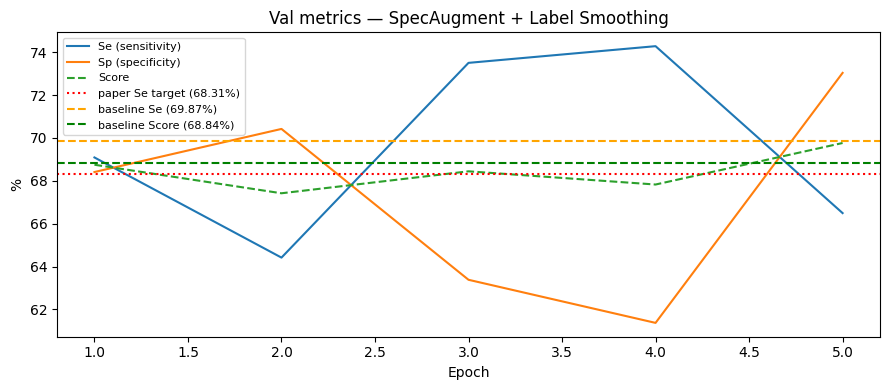

Best val  Se=66.49%  Sp=73.04%  Score=69.77%  (epoch 5)
Baseline  Se=69.87%  Score=68.84%


In [6]:
import matplotlib.pyplot as plt

epochs = [m["epoch"] for m in results["history"]]
se     = [m["se"] * 100 for m in results["history"]]
sp     = [m["sp"] * 100 for m in results["history"]]
score  = [m["score"] * 100 for m in results["history"]]

# Baseline epoch 1 reference
BASELINE_SE    = 69.87
BASELINE_SCORE = 68.84

plt.figure(figsize=(9, 4))
plt.plot(epochs, se,    label="Se (sensitivity)")
plt.plot(epochs, sp,    label="Sp (specificity)")
plt.plot(epochs, score, label="Score", linestyle="--")
plt.axhline(68.31,         color="red",   linestyle=":",  label="paper Se target (68.31%)")
plt.axhline(BASELINE_SE,   color="orange",linestyle="--", label=f"baseline Se ({BASELINE_SE}%)")
plt.axhline(BASELINE_SCORE,color="green", linestyle="--", label=f"baseline Score ({BASELINE_SCORE}%)")
plt.xlabel("Epoch")
plt.ylabel("%")
plt.title("Val metrics — SpecAugment + Label Smoothing")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

best = max(results["history"], key=lambda m: m["score"])
print(f"Best val  Se={best['se']*100:.2f}%  Sp={best['sp']*100:.2f}%  Score={best['score']*100:.2f}%  (epoch {best['epoch']})")
print(f"Baseline  Se={BASELINE_SE}%  Score={BASELINE_SCORE}%")

## Final test evaluation

Load the best-val-Score checkpoint and run once on the held-out test split.

In [7]:
from src.training.train_loop import evaluate_test
import numpy as np

print("Evaluating best checkpoint vs final epoch...\n")

m_best = evaluate_test(results["best_checkpoint"], CACHE_PATH, config, device)
m_last = evaluate_test(results["last_checkpoint"], CACHE_PATH, config, device)

print(f"{'Checkpoint':<30} {'Se':>7} {'Sp':>7} {'Score':>7}")
print("-" * 55)
print(f"{'best (val Score)  ' + m_best['checkpoint']:<30} {m_best['se']*100:>6.2f}% {m_best['sp']*100:>6.2f}% {m_best['score']*100:>6.2f}%")
print(f"{'last (final epoch) ' + m_last['checkpoint']:<30} {m_last['se']*100:>6.2f}% {m_last['sp']*100:>6.2f}% {m_last['score']*100:>6.2f}%")
print()
print("Reference paper:   Se=68.31%  Sp=67.89%  Score=68.10%")
print("AST baseline:      Se=69.87%  Sp=67.81%  Score=68.84%")
print("\nConfusion matrix — best checkpoint (rows=true, cols=pred):")
print(np.array(m_best["confusion_matrix"]))
print("\nConfusion matrix — last checkpoint (rows=true, cols=pred):")
print(np.array(m_last["confusion_matrix"]))
m_test = m_best  # used by save cell


Evaluating best checkpoint vs final epoch...



Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Checkpoint                          Se      Sp   Score
-------------------------------------------------------
best (val Score)  best_score_epoch05.pt  71.11%  57.69%  64.40%
last (final epoch) last.pt      71.11%  57.69%  64.40%

Reference paper:   Se=68.31%  Sp=67.89%  Score=68.10%
AST baseline:      Se=69.87%  Sp=67.81%  Score=68.84%

Confusion matrix — best checkpoint (rows=true, cols=pred):
[[911 405 236  27]
 [202 417  14  16]
 [108  53 135  89]
 [ 30  24  44  45]]

Confusion matrix — last checkpoint (rows=true, cols=pred):
[[911 405 236  27]
 [202 417  14  16]
 [108  53 135  89]
 [ 30  24  44  45]]


In [8]:
import json, shutil
from IPython.display import FileLink, display
from pathlib import Path

save_dir = Path(SAVE_DIR)
save_dir.mkdir(parents=True, exist_ok=True)

results_path = save_dir / "results.json"
results_path.write_text(json.dumps({
    "experiment": config.get("model_type", "ast"),
    "config": config,
    "test_best": m_best,
    "test_last": m_last,
    "best_val": best,
    "history": results["history"],
}, indent=2))

exp = config.get("model_type", "ast")
shutil.copy(results_path, f"/kaggle/working/results_{exp}.json")
if results["best_checkpoint"] and Path(results["best_checkpoint"]).exists():
    shutil.copy(results["best_checkpoint"], f"/kaggle/working/best_checkpoint_{exp}.pt")
if results["last_checkpoint"] and Path(results["last_checkpoint"]).exists():
    shutil.copy(results["last_checkpoint"], f"/kaggle/working/last_checkpoint_{exp}.pt")

print(f"results saved: {results_path}")
display(FileLink(f"/kaggle/working/results_{exp}.json"))
display(FileLink(f"/kaggle/working/best_checkpoint_{exp}.pt"))
display(FileLink(f"/kaggle/working/last_checkpoint_{exp}.pt"))


results saved: /kaggle/working/checkpoints/specaugment/results.json


/kaggle/working/results_ast.json

/kaggle/working/best_checkpoint_ast.pt

/kaggle/working/last_checkpoint_ast.pt